# Data Preparation & Exploratory Data Analysis

## Project Goal

The goal of this notebook is to prepare the marketing A/B testing dataset and perform exploratory data analysis.

The dataset contains information about users who were exposed either to an advertising campaign or to a public service announcement. The main business question is whether the advertising campaign increased conversion.

This notebook focuses on:

- understanding the dataset structure;
- checking data quality;
- analyzing group distribution;
- exploring conversion patterns;
- examining ad exposure by day and hour.


## Load Data

The dataset is loaded from a CSV file. Each row represents one user and contains information about the experimental group, conversion status, number of ads shown, and the time when the user saw the highest number of ads.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## Dataset Overview

This section provides a general overview of the dataset size, columns, and data types.

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 588,101
Columns: 7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [6]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


## Rename Columns

Column names are standardized to make the code cleaner and easier to read.

In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['unnamed:_0', 'user_id', 'test_group', 'converted', 'total_ads',
       'most_ads_day', 'most_ads_hour'],
      dtype='object')

In [8]:
df.head()

,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## Missing Values

Before analysis, we check whether the dataset contains missing values.

In [9]:
df.isna().sum()

,0
unnamed:_0,0
user_id,0
test_group,0
converted,0
total_ads,0
most_ads_day,0
most_ads_hour,0


## Duplicate Rows

Duplicate rows may distort conversion rates and group sizes, so they should be checked before analysis.

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df.duplicated()].head()

,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour


## Unique Values

This section checks the unique values in categorical columns.

In [14]:
df.nunique()

,0
unnamed:_0,588101
user_id,588101
test_group,2
converted,2
total_ads,807
most_ads_day,7
most_ads_hour,24


In [15]:
df["test_group"].value_counts()

,count
test_group,
ad,564577
psa,23524


In [16]:
df["converted"].value_counts()

,count
converted,
False,573258
True,14843


In [17]:
df["most_ads_day"].value_counts()

,count
most_ads_day,
Friday,92608
Monday,87073
Sunday,85391
Thursday,82982
Saturday,81660
Wednesday,80908
Tuesday,77479


## Basic Metrics

The main metric for this project is conversion rate. It shows the share of users who completed the target action.

In [18]:
total_users = df["user_id"].nunique()
total_conversions = df["converted"].sum()
overall_conversion_rate = df["converted"].mean() * 100

print(f"Total users: {total_users:,}")
print(f"Total conversions: {total_conversions:,}")
print(f"Overall conversion rate: {overall_conversion_rate:.2f}%")

Total users: 588,101
Total conversions: 14,843
Overall conversion rate: 2.52%


# Exploratory Data Analysis

## Test Group Distribution

First, we check how users are distributed between the test and control groups.

In [19]:
group_counts = (
    df["test_group"]
    .value_counts()
    .reset_index()
)

group_counts.columns = ["test_group", "users"]

group_counts

,test_group,users
0,ad,564577
1,psa,23524


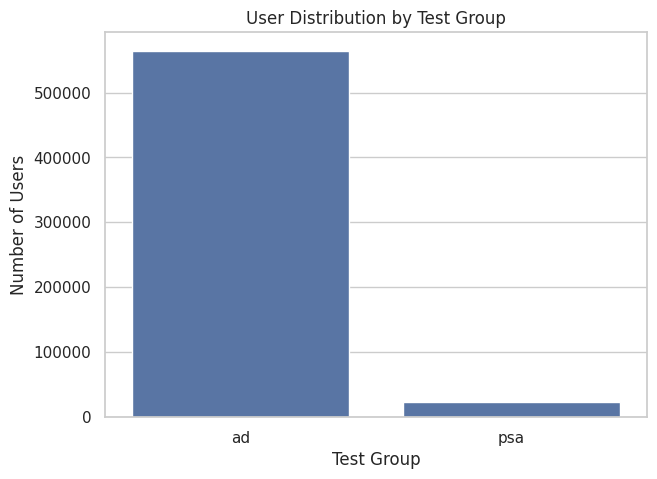

In [20]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=group_counts,
    x="test_group",
    y="users"
)

plt.title("User Distribution by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Number of Users")
plt.show()

#### Observation

The dataset contains users from both experimental groups. Before running the A/B test, it is important to check whether the groups are reasonably represented.

## Conversion Distribution

This chart shows the overall distribution of converted and non-converted users.

In [21]:
conversion_counts = (
    df["converted"]
    .value_counts()
    .reset_index()
)

conversion_counts.columns = ["converted", "users"]

conversion_counts

,converted,users
0,False,573258
1,True,14843


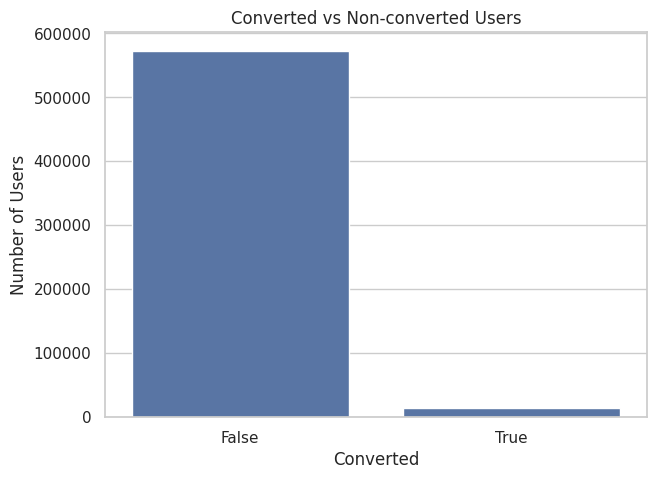

In [22]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=conversion_counts,
    x="converted",
    y="users"
)

plt.title("Converted vs Non-converted Users")
plt.xlabel("Converted")
plt.ylabel("Number of Users")
plt.show()

#### Observation

Most users did not convert, which is typical for marketing and advertising campaigns. The conversion rate should be analyzed separately for each experimental group.

## Conversion Rate by Test Group

This is one of the most important EDA steps. It compares the conversion rate between the advertising group and the control group.

In [23]:
conversion_by_group = (
    df.groupby("test_group")["converted"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

conversion_by_group.columns = [
    "test_group",
    "users",
    "conversions",
    "conversion_rate"
]

conversion_by_group["conversion_rate_%"] = (
    conversion_by_group["conversion_rate"] * 100
).round(2)

conversion_by_group

,test_group,users,conversions,conversion_rate,conversion_rate_%
0,ad,564577,14423,0.025547,2.55
1,psa,23524,420,0.017854,1.79


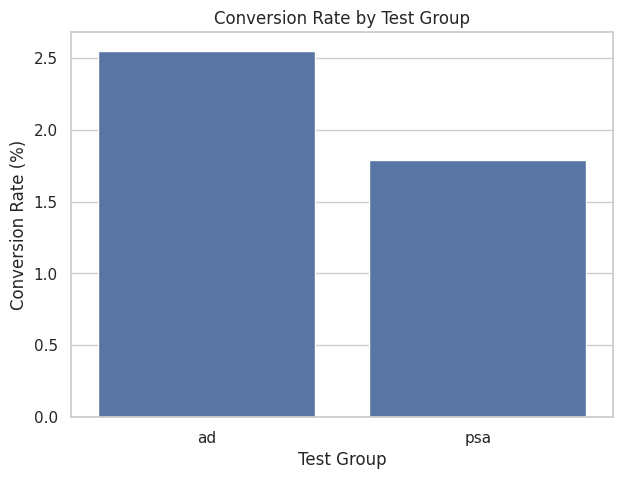

In [24]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=conversion_by_group,
    x="test_group",
    y="conversion_rate_%"
)

plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.show()

#### Observation

The conversion rate differs between the groups. However, this visual comparison alone is not enough to conclude that the difference is statistically significant. This will be tested in the next notebook.

## Distribution of Total Ads

This section examines how many ads users were exposed to.

In [25]:
df["total_ads"].describe()

,total_ads
count,588101.000000
mean,24.820876
std,43.715181
min,1.000000
25%,4.000000
50%,13.000000
75%,27.000000
max,2065.000000


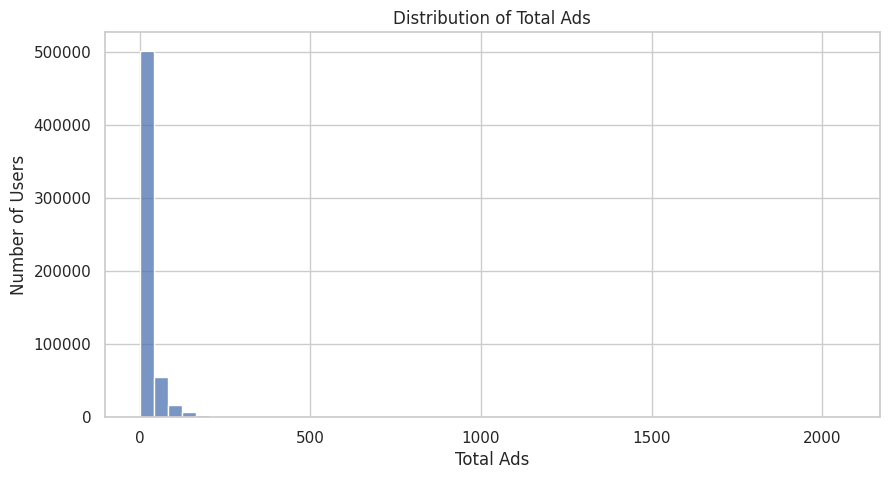

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="total_ads",
    bins=50
)

plt.title("Distribution of Total Ads")
plt.xlabel("Total Ads")
plt.ylabel("Number of Users")
plt.show()

#### Observation

The distribution of ad exposure is right-skewed: most users saw a relatively small number of ads, while some users were exposed to many more ads.

In [27]:
ads_99 = df["total_ads"].quantile(0.99)

df_ads_filtered = df[df["total_ads"] <= ads_99]

print(f"99th percentile of total ads: {ads_99}")
print(f"Filtered dataset size: {df_ads_filtered.shape[0]:,}")

99th percentile of total ads: 202.0
Filtered dataset size: 582,291


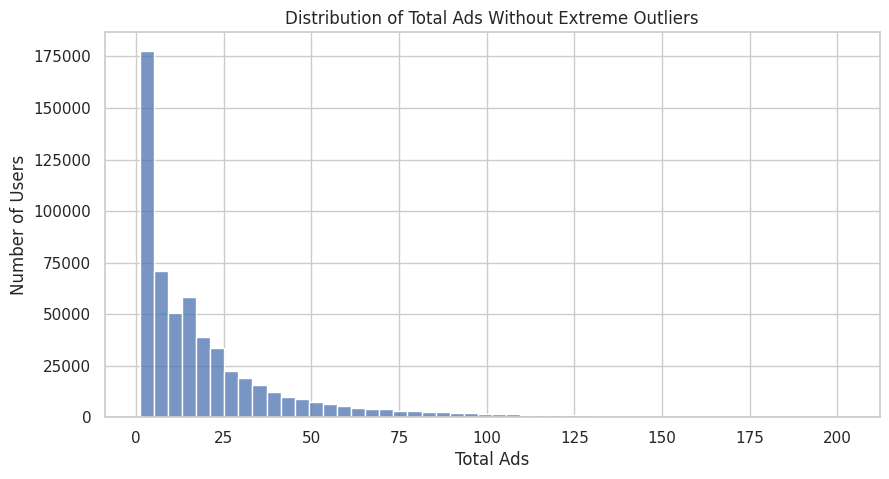

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_ads_filtered,
    x="total_ads",
    bins=50
)

plt.title("Distribution of Total Ads Without Extreme Outliers")
plt.xlabel("Total Ads")
plt.ylabel("Number of Users")
plt.show()

## Total Ads by Conversion Status

This boxplot compares ad exposure between users who converted and users who did not.

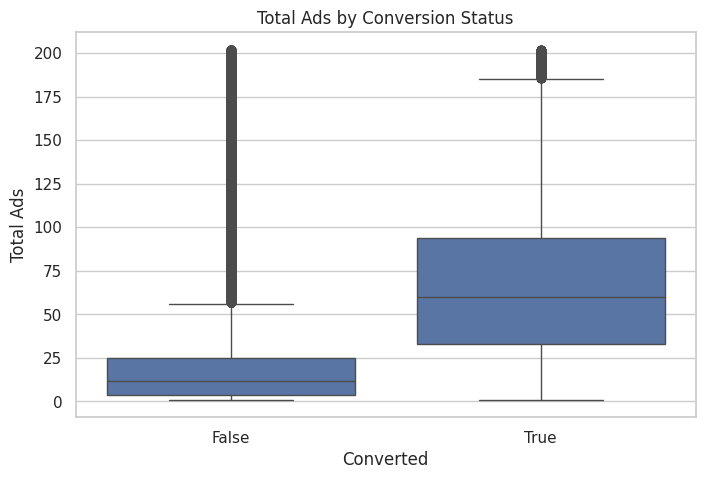

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_ads_filtered,
    x="converted",
    y="total_ads"
)

plt.title("Total Ads by Conversion Status")
plt.xlabel("Converted")
plt.ylabel("Total Ads")
plt.show()

#### Observation

Converted users may have been exposed to a different number of ads compared to non-converted users. This suggests that ad frequency could be associated with conversion behavior.

## Average Number of Ads by Conversion Status

This section compares the average number of ads seen by converted and non-converted users.

In [30]:
avg_ads_by_conversion = (
    df.groupby("converted")["total_ads"]
    .mean()
    .reset_index()
)

avg_ads_by_conversion["total_ads"] = avg_ads_by_conversion["total_ads"].round(2)

avg_ads_by_conversion

,converted,total_ads
0,False,23.29
1,True,83.89


In [31]:
avg_ads_by_conversion = (
    df.groupby("converted")["total_ads"]
    .mean()
    .reset_index()
)

avg_ads_by_conversion["total_ads"] = avg_ads_by_conversion["total_ads"].round(2)

avg_ads_by_conversion

,converted,total_ads
0,False,23.29
1,True,83.89


#### Observation

The average number of ads differs between converted and non-converted users, which may indicate that ad exposure is related to conversion probability.

## Most Ads Day Distribution

This chart shows on which days users most often saw the highest number of ads.

In [32]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

ads_by_day = (
    df["most_ads_day"]
    .value_counts()
    .reindex(day_order)
    .reset_index()
)

ads_by_day.columns = ["day", "users"]

ads_by_day

,day,users
0,Monday,87073
1,Tuesday,77479
2,Wednesday,80908
3,Thursday,82982
4,Friday,92608
5,Saturday,81660
6,Sunday,85391


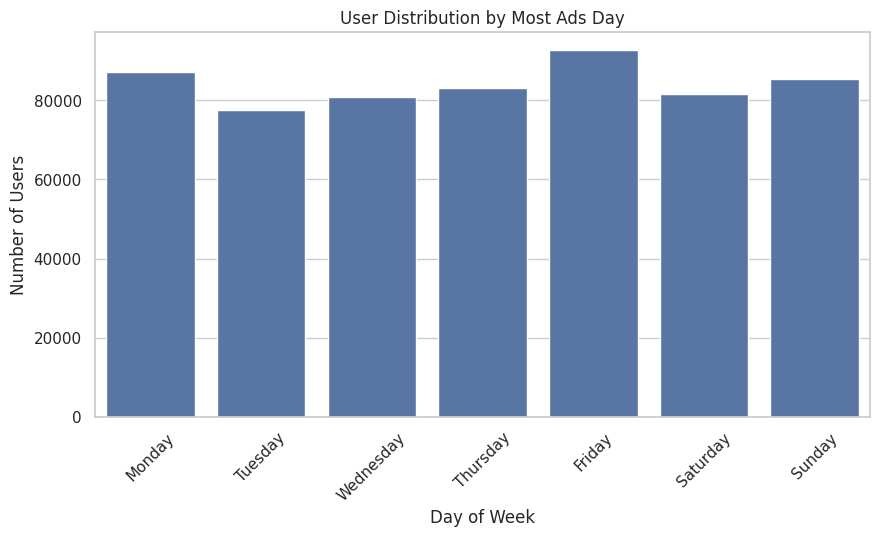

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=ads_by_day,
    x="day",
    y="users"
)

plt.title("User Distribution by Most Ads Day")
plt.xlabel("Day of Week")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

#### Observation

Ad exposure is not evenly distributed across days of the week. Some days generate noticeably higher user activity.

## Conversion Rate by Day

This chart shows how conversion rate changes depending on the day when users saw the highest number of ads.

In [35]:
conversion_by_day = (
    df.groupby("most_ads_day")["converted"]
    .mean()
    .reindex(day_order)
    .reset_index()
)

conversion_by_day.columns = ["day", "conversion_rate"]

conversion_by_day["conversion_rate_%"] = (
    conversion_by_day["conversion_rate"] * 100
).round(2)

conversion_by_day

,day,conversion_rate,conversion_rate_%
0,Monday,0.032812,3.28
1,Tuesday,0.029840,2.98
2,Wednesday,0.024942,2.49
3,Thursday,0.021571,2.16
4,Friday,0.022212,2.22
5,Saturday,0.021051,2.11
6,Sunday,0.024476,2.45


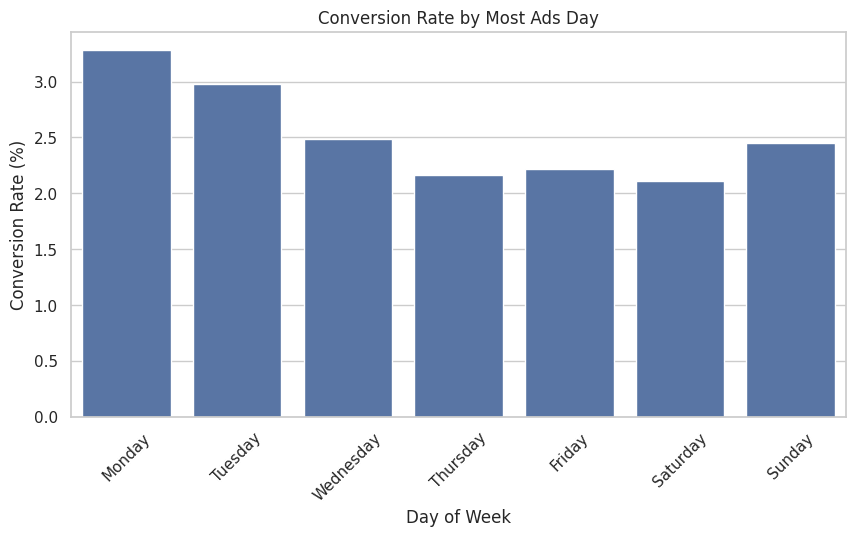

In [36]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=conversion_by_day,
    x="day",
    y="conversion_rate_%"
)

plt.title("Conversion Rate by Most Ads Day")
plt.xlabel("Day of Week")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

#### Observation

Conversion rate varies by day of the week. This may indicate that users respond differently to ads depending on timing.

## Most Ads Hour Distribution

This chart shows at which hours users most often saw the highest number of ads.

In [37]:
ads_by_hour = (
    df["most_ads_hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)

ads_by_hour.columns = ["hour", "users"]

ads_by_hour.head()

,hour,users
0,0,5536
1,1,4802
2,2,5333
3,3,2679
4,4,722


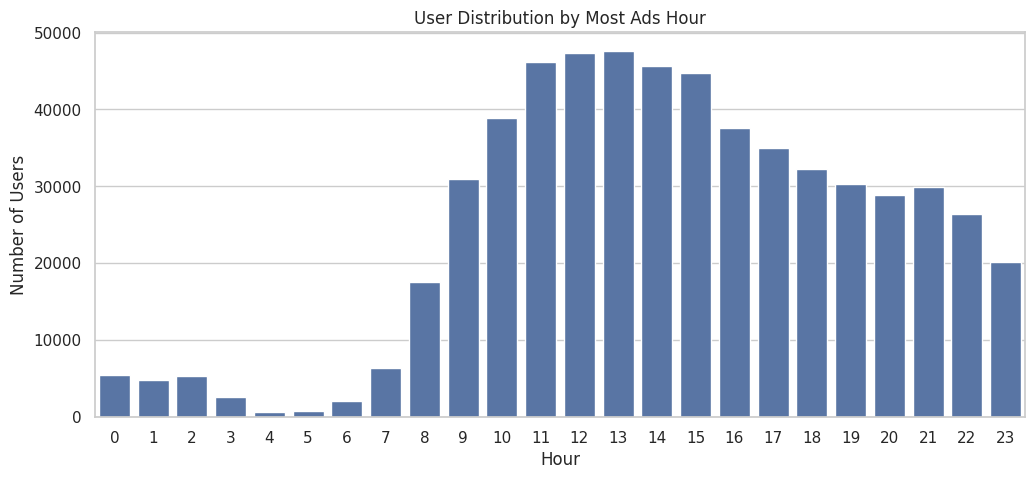

In [38]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=ads_by_hour,
    x="hour",
    y="users"
)

plt.title("User Distribution by Most Ads Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Users")
plt.show()

#### Observation

Ad exposure varies throughout the day, with some hours showing much higher activity than others.

## Conversion Rate by Hour

This chart shows how conversion rate changes by the hour when users saw the highest number of ads.

In [39]:
conversion_by_hour = (
    df.groupby("most_ads_hour")["converted"]
    .mean()
    .reset_index()
)

conversion_by_hour["conversion_rate_%"] = (
    conversion_by_hour["converted"] * 100
).round(2)

conversion_by_hour.head()

,most_ads_hour,converted,conversion_rate_%
0,0,0.018425,1.84
1,1,0.012911,1.29
2,2,0.007313,0.73
3,3,0.010452,1.05
4,4,0.015235,1.52


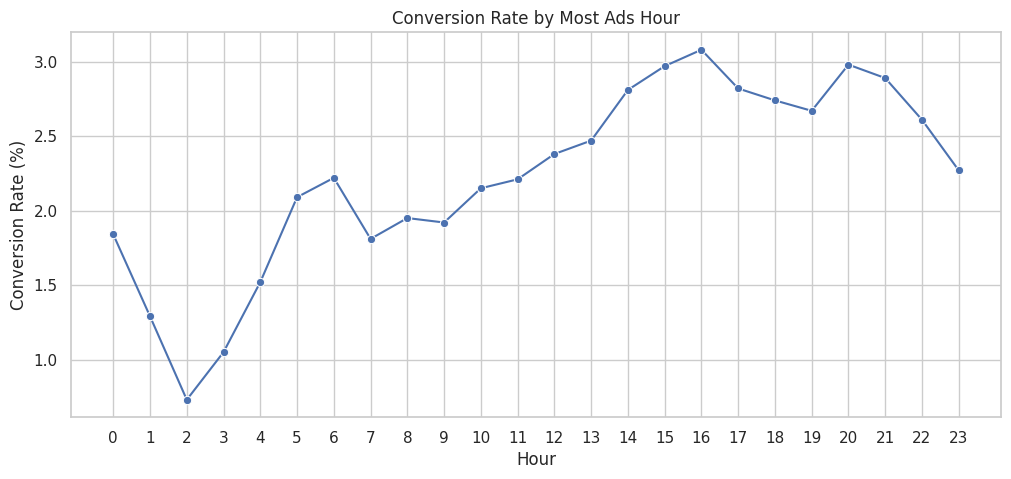

In [40]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=conversion_by_hour,
    x="most_ads_hour",
    y="conversion_rate_%",
    marker="o"
)

plt.title("Conversion Rate by Most Ads Hour")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate (%)")
plt.xticks(range(0, 24))
plt.show()

#### Observation

Conversion rates differ by hour, which may help identify more effective time windows for advertising.

## Conversion Rate by Group and Day

This section compares daily conversion rates between the advertising and control groups.

In [41]:
conversion_group_day = (
    df.groupby(["most_ads_day", "test_group"])["converted"]
    .mean()
    .reset_index()
)

conversion_group_day["conversion_rate_%"] = (
    conversion_group_day["converted"] * 100
).round(2)

conversion_group_day["most_ads_day"] = pd.Categorical(
    conversion_group_day["most_ads_day"],
    categories=day_order,
    ordered=True
)

conversion_group_day = conversion_group_day.sort_values("most_ads_day")

conversion_group_day.head()

,most_ads_day,test_group,converted,conversion_rate_%
2,Monday,ad,0.033241,3.32
3,Monday,psa,0.022559,2.26
10,Tuesday,ad,0.030440,3.04
11,Tuesday,psa,0.014448,1.44
12,Wednesday,ad,0.025356,2.54


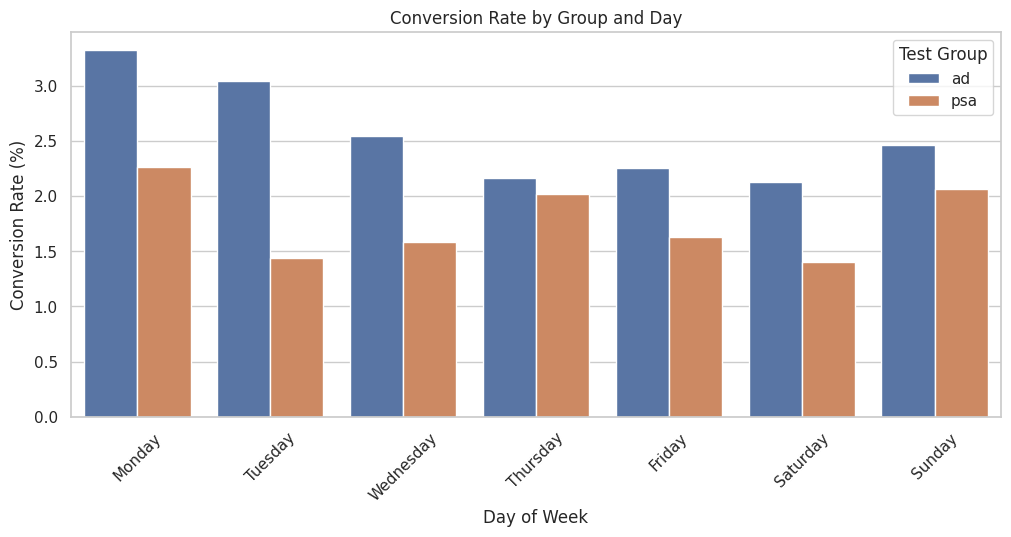

In [42]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=conversion_group_day,
    x="most_ads_day",
    y="conversion_rate_%",
    hue="test_group"
)

plt.title("Conversion Rate by Group and Day")
plt.xlabel("Day of Week")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Test Group")
plt.show()

#### Observation

The difference between groups may vary across days of the week. This can help identify whether the advertising campaign performs better on specific days.

## Conversion Rate by Group and Hour

This chart compares hourly conversion rates between the advertising and control groups.

In [43]:
conversion_group_hour = (
    df.groupby(["most_ads_hour", "test_group"])["converted"]
    .mean()
    .reset_index()
)

conversion_group_hour["conversion_rate_%"] = (
    conversion_group_hour["converted"] * 100
).round(2)

conversion_group_hour.head()

,most_ads_hour,test_group,converted,conversion_rate_%
0,0,ad,0.019213,1.92
1,0,psa,0.000000,0.00
2,1,ad,0.013434,1.34
3,1,psa,0.000000,0.00
4,2,ad,0.007570,0.76


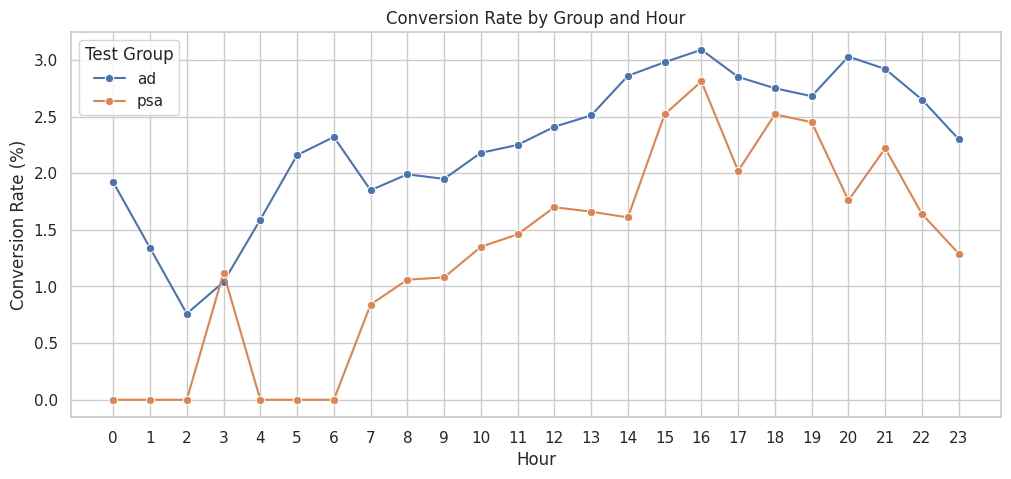

In [44]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=conversion_group_hour,
    x="most_ads_hour",
    y="conversion_rate_%",
    hue="test_group",
    marker="o"
)

plt.title("Conversion Rate by Group and Hour")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate (%)")
plt.xticks(range(0, 24))
plt.legend(title="Test Group")
plt.show()

#### Observation

Hourly conversion patterns may differ between the test and control groups. This provides additional context before running the formal statistical test.

# Key Findings

- The dataset contains users from two experimental groups: advertising and control.
- The main target variable is conversion status.
- The overall conversion rate is relatively low, which is typical for marketing campaigns.
- Conversion rate differs between the advertising and control groups.
- Ad exposure is unevenly distributed across days and hours.
- Users who converted tend to have different ad exposure patterns compared to users who did not convert.
- Visual differences between groups should be confirmed using statistical hypothesis testing in the next notebook.

## Save Cleaned Dataset

The cleaned dataset is saved for further statistical analysis in the next notebook.

In [46]:
from google.colab import files

files.download("marketing_ab_test_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>